In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.image as mpimg
from PIL import Image

In [18]:
test_case = "apartment_s2"
image_path = "../media/.apartment_cropped.png"

main_df = pd.DataFrame()

for participant in ["p1", "p2", "p3", "p4", "p6", "p7"]:
    df = pd.read_csv(f"../trajectory/{participant}/{participant}_{test_case}_center.csv")
    df = df.iloc[1:]
    # df = pd.read_csv(f"../trajectory/{test_case}_center.csv", )
    main_df = pd.concat([main_df, df], ignore_index=True)

main_df.head()

,x,y
0,-3.338442,-4.752753
1,-3.949538,-4.586692
2,-8.344821,-4.090077
3,-8.183825,-0.517526
4,-3.242154,-5.398641


/tmp/ipykernel_43958/1607435256.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


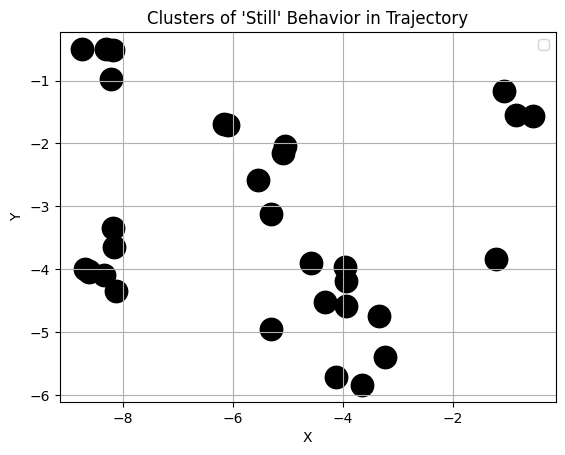

In [19]:
for _, row in main_df.iterrows():
    plt.scatter(row['x'], row['y'], marker='o', s=200, linewidths=3, color='black')

plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [38]:
gmm = GaussianMixture(
    n_components=6,        # number of Gaussian components
    covariance_type='full',
    random_state=42
)

gmm.fit(main_df)               
labels = gmm.predict(main_df)

In [39]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(xy=position, width=nsig * width, height=nsig * height,
                             angle=angle, **kwargs))
        
def plot_gmm(gmm : GaussianMixture, X, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    ax.scatter(X['x'], X['y'], c=labels, cmap='viridis', s=50, edgecolor='k')
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(position=pos, covariance=covar, ax=ax, alpha=w * w_factor)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


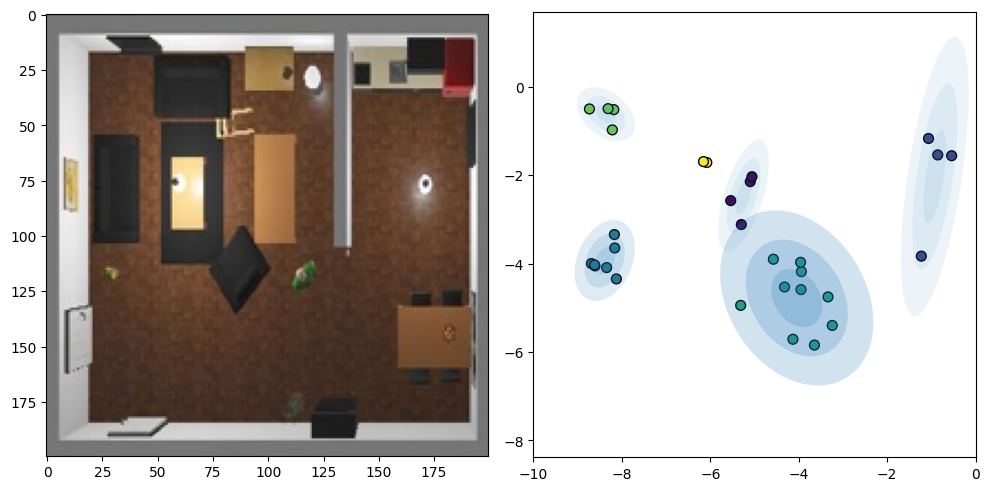

In [40]:
img = Image.open(image_path)
img_resized = img.resize((200, 200))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_resized)

# scatter points colored by hard labels
# ax2.scatter(main_df['x'], main_df['y'], c=labels, cmap='viridis', s=50, edgecolor='k')

# plot Gaussian centers
# ax2.scatter(
#     gmm.means_[:, 0],
#     gmm.means_[:, 1],
#     s=300,
#     c='red',
#     marker='X',
#     label='Centers'
# )
plot_gmm(gmm, main_df, ax=ax2)

if "hall" in test_case.lower():
    ax2.set_xlim(-3.1, 3.5)
    ax2.set_ylim(-11, 11.26)
elif "apartment" in test_case.lower():
    ax2.set_xlim(-10, 0)
    ax2.set_ylim(-6.5, -0.2)
elif "break" in test_case.lower():
    ax2.set_xlim(-6.7, 7)
    ax2.set_ylim(-2.8, 5)

plt.tight_layout()
plt.show()

In [51]:
def plot_and_save_gmm(test_case):
    # test_case = "apartment_s2"
    image_path = f"../media/.{test_case[:-3]}_cropped.png"

    main_df = pd.DataFrame()

    for participant in ["p1", "p2", "p3", "p4", "p6", "p7"]:
        df = pd.read_csv(f"../trajectory/{participant}/{participant}_{test_case}_center.csv")
        df = df.iloc[1:]
        # df = pd.read_csv(f"../trajectory/{test_case}_center.csv", )
        main_df = pd.concat([main_df, df], ignore_index=True)
    
    gmm = GaussianMixture(
    n_components=6,        # number of Gaussian components
    covariance_type='full',
    random_state=42
    )

    gmm.fit(main_df)               
    labels = gmm.predict(main_df)

    img = Image.open(image_path)
    img_resized = img.resize((200, 200))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(img_resized)

    plot_gmm(gmm, main_df, ax=ax2)

    ax2.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        s=300,
        c='red',
        marker='X',
        label='Centers'
    )

    if "hall" in test_case.lower():
        ax2.set_xlim(-3.1, 3.5)
        ax2.set_ylim(-11, 11.26)
    elif "apartment" in test_case.lower():
        ax2.set_xlim(-10, 0)
        ax2.set_ylim(-6.5, -0.2)
    elif "break" in test_case.lower():
        ax2.set_xlim(-6.7, 7)
        ax2.set_ylim(-2.8, 5)

    plt.tight_layout()
    plt.savefig(f"../media/gmm_{test_case}.png")
    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


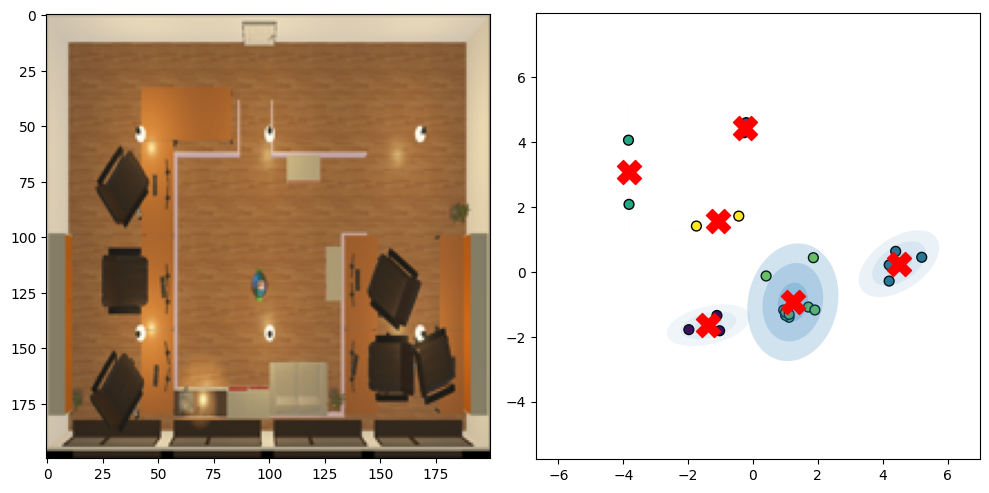

In [ ]:
scenarios = ["apartment_s2", "apartment_s3", "hall_s2", "hall_s3", "break_room_s2", "break_room_s3"]
for scenario in scenarios:
    plot_and_save_gmm(scenario)